# Extraction of $\delta_*(\Lambda)$

This notebook models the linearized ("tangent") response of the SYK
Green's function directly against the known conformal-perturbation-theory (CPT) shapes
$f_0$, $f_{00}$, $f_1$, rather than a generic polynomial-in-$1/\beta J$ correction, an
eigenvector projection, or a shared-intercept regression.

**Physical setup.** The $q=4$ Majorana SYK model's imaginary-time Schwinger-Dyson equations are

$$
\Sigma(\tau)=J_2^2G(\tau)+J_4^2G(\tau)^3,
\qquad
G(i\omega_n)^{-1}=-i\omega_n-\Sigma(i\omega_n)-K(i\omega_n),
$$

where $K$ is an external source. Setting $K=0$ and solving self-consistently gives the
**undeformed equilibrium saddle** $G_*(\tau)$. Linearizing around that saddle in response to a
small source $K^{(a)}$ gives the **tangent equation**

$$
\left[I-\mathcal M_*\right]\dot G^{(a)}=G_*^2K^{(a)},
\qquad
\mathcal M_*[\dot G](i\omega_n)=G_*(i\omega_n)^2\,
\mathcal F\!\left[\left(J_2^2+3J_4^2G_*(\tau)^2\right)\mathcal F^{-1}[\dot G]\right]\!(i\omega_n),
$$

solved here with matrix-free GMRES (no dense $N_\tau\times N_\tau$ Jacobian). Two regulated
sources are used, a "linear" and a "cubic" kernel sharing one UV regulator scale $\Lambda$:

$$
K^{(1)}(i\omega_n)=-i\omega_n\left[\frac{\Lambda^2}{\Lambda^2+\omega_n^2}\right]^2,
\qquad
K^{(3)}(i\omega_n)=\frac{(-i\omega_n)^3}{J_4^2}\left[\frac{\Lambda^2}{\Lambda^2+\omega_n^2}\right]^2.
$$

The physical target is $\delta_*(\Lambda)$, the coefficient for which the combined response
$\dot G^{(3)}+\delta_*\dot G^{(1)}$ cancels the leading ($h_0$, "soft mode") term of the tangent
response, leaving a response dominated by the first subleading primary ($h_1$) instead.

$\delta_*=-\kappa_0^{(3)}/\kappa_0^{(1)}$, where $\kappa_0^{(a)}$ is the amplitude of the soft mode in $\dot G^{(a)}$ — but *how* we extract that amplitude from a finite-$\beta$ numerical solution comes from the tangent response against the two lowest known CPT shapes,

$$
\frac{\dot G^{(a)}(\tau)}{G_c(\tau)}\approx
\kappa_0^{(a)}\underbrace{\left[-\frac{f_0(u)}{B}-\frac{2a_{00}\alpha_0 f_{00}(u)}{B^2}\right]}_{\Phi_0(u,B)}
+\kappa_1^{(a)}\underbrace{\left[-\frac{f_1(u)}{B^{h_1-1}}\right]}_{\Phi_1(u,B)},
\qquad B=\beta J_4,\ u=\tau/\beta,
$$

a linear two-parameter fit with no free window-dependent coefficients. Its main finding,
reproduced below, is that $\kappa_0^{(1)}(\beta)$ is not flat over the modest range
$\beta J\in[12,60]$ used elsewhere — it passes through a transient and only settles onto a genuine plateau after some large $\beta J$ that depends on $\Lambda$ choice. Pushing the grid out to resolves this and gives a
converged $\delta_*(\Lambda)$ that differs from naive $\beta J\le 60$ read-off.

**Three other methods tried** (full implementation in `syk_matsubara_kernel_methods.ipynb`):
- *Template ratio*: projects $\dot G^{(a)}/G_c$ onto the single leading shape $f_0(u)$ at each
  finite $\beta$, then Richardson-extrapolates $\beta J\to\infty$. Cheapest, but flagged
  unreliable there (a sign issue traced to the single-template model being too coarse).
- *Eigenvector projection*: builds $[I-\mathcal M_*]$ as a dense matrix at finite $(\beta,N_\tau)$
  and projects onto its left eigenvector.
- *Shared-intercept regression*: fits $\kappa_0^{(1)}(\beta)$, $\kappa_0^{(3)}(\beta)$ jointly
  across many $\beta$ and fit-window choices, sharing one $\beta\to\infty$ intercept, with a
  bootstrap-style ensemble for the uncertainty interval.

A brief numerical comparison against these three is given in the closing section, for context.

In [1]:
from __future__ import annotations

from pathlib import Path
from typing import Any, Optional
import time

import numpy as np
import pandas as pd
import mpmath as mp
import matplotlib.pyplot as plt
import scipy

## Parameters

Two $\beta$ grids are used throughout: a "moderate" grid ($\beta J\le 60$) matching what the other
three methods in the full notebook use, and a "large" grid ($\beta J$ up to $400$) that is needed
to see $\kappa_0^{(1)}(\beta)$ actually reach its plateau. $N_\tau=30\,\beta J$ is used everywhere
(a resolution check below confirms this is sufficient for this particular fit, which — unlike the
equilibrium $f_{00}$ extraction — does not need anywhere near $N_\tau=480\,\beta J$).

In [53]:
# Physical parameters (undeformed equilibrium q=4 Majorana SYK, J2=0)
J4 = 1.0
J2 = 0.0

small_betas = [12.0, 18.0, 24.0, 30.0]
moderate_betas = [12.0, 18.0, 24.0, 30.0, 36.0, 42.0, 48.0, 54.0, 60.0]
large_betas = [80.0, 100.0, 140.0, 180.0, 240.0, 300.0, 400.0]
all_betas = small_betas + moderate_betas + large_betas

# Lambda grid, restricted to Lambda<=1: Lambda=1 is flagged elsewhere as not a particularly
# reliable regulator, and Lambda>~1 is where the independent shared-intercept method's own
# stability diagnostics start failing.
sweep_Lambda = [0.40, 0.50, 0.65, 0.75, 0.90, 1.00]

# N_tau = NTAU_MULT * beta*J4 gives a fixed UV resolution in units of beta*J4;
# the resolution check below confirms NTAU_MULT=30 is sufficient for this fit.
KAPPA_FIT_NTAU_MULT = 30

# Lower beta-J cut used for the "pre-asymptotic" comparison estimate
PREASYMPTOTIC_BETA_MIN = 30.0

equilibrium_mixing = 0.10
equilibrium_tol = 1e-11
equilibrium_max_iter = 20_000

tangent_rtol = 1e-10
tangent_restart = 150
tangent_maxiter = 2_000

output_dir = Path("matsubara_tangent_output")
output_dir.mkdir(parents=True, exist_ok=True)

## Fermionic Matsubara transforms

Antiperiodic grid $\tau_j=(j+\tfrac12)\beta/N_\tau$, $\omega_n=2\pi(n+\tfrac12)/\beta$, with
$$
F(i\omega_n)=\int_0^\beta d\tau\,e^{-i\omega_n\tau}F(\tau),
\qquad
F(\tau)=\frac1\beta\sum_n e^{+i\omega_n\tau}F(i\omega_n),
$$
implemented via FFT with the appropriate half-grid phase twist.

In [54]:
def fermionic_matsubara_grid(
    beta: float,
    N_tau: int,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    if N_tau <= 0 or N_tau % 2 != 0:
        raise ValueError("N_tau must be a positive even integer.")

    j = np.arange(N_tau)
    tau = (j + 0.5) * beta / N_tau

    n = np.arange(-N_tau // 2, N_tau // 2)
    omega_n = 2.0 * np.pi * (n + 0.5) / beta

    return tau, omega_n, n


def fermion_tau_to_iw(f_tau: np.ndarray, beta: float) -> np.ndarray:
    # F(iw_n) = int_0^beta dtau exp(-i w_n tau) F(tau).
    f_tau = np.asarray(f_tau, dtype=np.complex128)
    N_tau = f_tau.size

    j = np.arange(N_tau)
    n = np.arange(-N_tau // 2, N_tau // 2)

    twisted_tau = f_tau * np.exp(-1j * np.pi * j / N_tau)

    return (
        (beta / N_tau)
        * np.exp(-1j * np.pi * (n + 0.5) / N_tau)
        * np.fft.fftshift(np.fft.fft(twisted_tau))
    )


def fermion_iw_to_tau(f_iw: np.ndarray, beta: float) -> np.ndarray:
    # F(tau) = (1/beta) sum_n exp(+i w_n tau) F(iw_n).
    f_iw = np.asarray(f_iw, dtype=np.complex128)
    N_tau = f_iw.size

    j = np.arange(N_tau)
    n = np.arange(-N_tau // 2, N_tau // 2)

    twisted_iw = f_iw * np.exp(+1j * np.pi * n / N_tau)

    return (
        (N_tau / beta)
        * np.exp(+1j * np.pi * (j + 0.5) / N_tau)
        * np.fft.ifft(np.fft.ifftshift(twisted_iw))
    )

## Undeformed equilibrium Matsubara saddle

Fixed-point iteration with linear mixing:
$$
G_*(i\omega_n)=\frac{1}{-i\omega_n-\Sigma_*(i\omega_n)-K(i\omega_n)},
\qquad
\Sigma_*(\tau)=J_2^2G_*(\tau)+J_4^2G_*(\tau)^3.
$$
$K=0$ gives the undeformed saddle used everywhere below.

In [55]:
def solve_equilibrium_matsubara(
    beta: float,
    J4: float,
    *,
    J2: float = 0.0,
    N_tau: int = 2048,
    K_iw: Optional[np.ndarray] = None,
    G_iw_init: Optional[np.ndarray] = None,
    mixing: float = 0.10,
    tol: float = 1e-11,
    max_iter: int = 20_000,
    verbose_every: int = 10**9,
) -> dict[str, Any]:
    tau, omega_n, n = fermionic_matsubara_grid(beta, N_tau)
    s_n = -1j * omega_n

    if K_iw is None:
        K_iw = np.zeros(N_tau, dtype=np.complex128)
    else:
        K_iw = np.asarray(K_iw, dtype=np.complex128)

    G_iw = 1.0 / s_n if G_iw_init is None else np.asarray(G_iw_init, dtype=np.complex128).copy()

    converged = False
    relative_update = np.inf

    for iteration in range(max_iter):
        G_tau = fermion_iw_to_tau(G_iw, beta)
        Sigma_tau = J2**2 * G_tau + J4**2 * G_tau**3
        Sigma_iw = fermion_tau_to_iw(Sigma_tau, beta)

        G_target = 1.0 / (s_n - Sigma_iw - K_iw)
        relative_update = float(
            np.linalg.norm(G_target - G_iw) / max(np.linalg.norm(G_target), 1e-30)
        )
        G_iw = (1.0 - mixing) * G_iw + mixing * G_target

        if iteration % verbose_every == 0 or relative_update < tol:
            print(f"  beta={beta:g} equilibrium iter={iteration:6d}  relative update={relative_update:.3e}")

        if relative_update < tol:
            converged = True
            break

    if not converged:
        raise RuntimeError(f"Equilibrium solver did not converge (final update={relative_update:.3e}).")

    G_tau = fermion_iw_to_tau(G_iw, beta)
    Sigma_tau = J2**2 * G_tau + J4**2 * G_tau**3
    Sigma_iw = fermion_tau_to_iw(Sigma_tau, beta)

    return {
        "beta": float(beta), "J2": float(J2), "J4": float(J4), "N_tau": int(N_tau),
        "tau": tau, "u": tau / beta, "omega_n": omega_n, "n": n, "s_n": s_n, "K_iw": K_iw,
        "G_tau": G_tau, "G_iw": G_iw, "Sigma_tau": Sigma_tau, "Sigma_iw": Sigma_iw,
        "iterations": int(iteration + 1), "relative_update": relative_update,
    }

## Engineered kernels and the linearized tangent equation

$K^{(1)}$, $K^{(3)}$ as defined above; the tangent equation is solved with matrix-free GMRES.

In [56]:
from scipy.sparse.linalg import LinearOperator, gmres


def make_engineered_kernel_components(omega_n: np.ndarray, J4: float, Lambda: float) -> dict[str, np.ndarray]:
    omega_n = np.asarray(omega_n, dtype=float)
    s_n = -1j * omega_n
    regulator = (Lambda**2 / (Lambda**2 + omega_n**2)) ** 2
    return {
        "regulator": regulator,
        "K1_iw": s_n * regulator,
        "K3_iw": (s_n**3 / J4**2) * regulator,
    }


def solve_matsubara_tangent(
    equilibrium: dict[str, Any],
    K_source_iw: np.ndarray,
    *,
    rtol: float = 1e-10,
    restart: int = 150,
    maxiter: int = 2_000,
) -> dict[str, Any]:
    beta = float(equilibrium["beta"])
    J2 = float(equilibrium["J2"])
    J4 = float(equilibrium["J4"])
    G_star_iw = np.asarray(equilibrium["G_iw"], dtype=np.complex128)
    G_star_tau = np.asarray(equilibrium["G_tau"], dtype=np.complex128)
    K_source_iw = np.asarray(K_source_iw, dtype=np.complex128)
    N_tau = G_star_iw.size

    dSigma_dG_tau = J2**2 + 3.0 * J4**2 * G_star_tau**2

    def tangent_operator(dG_iw: np.ndarray) -> np.ndarray:
        dG_iw = np.asarray(dG_iw, dtype=np.complex128)
        dG_tau = fermion_iw_to_tau(dG_iw, beta)
        dSigma_tau = dSigma_dG_tau * dG_tau
        dSigma_iw = fermion_tau_to_iw(dSigma_tau, beta)
        return dG_iw - G_star_iw**2 * dSigma_iw

    operator = LinearOperator(shape=(N_tau, N_tau), matvec=tangent_operator, dtype=np.complex128)
    rhs_iw = G_star_iw**2 * K_source_iw

    try:
        dG_iw, info = gmres(operator, rhs_iw, rtol=rtol, atol=0.0, restart=restart, maxiter=maxiter)
    except TypeError:
        dG_iw, info = gmres(operator, rhs_iw, tol=rtol, restart=restart, maxiter=maxiter)

    if info != 0:
        raise RuntimeError(f"GMRES did not converge for the tangent equation (info={info}).")

    dG_tau = fermion_iw_to_tau(dG_iw, beta)
    return {"K_source_iw": K_source_iw, "dG_iw": dG_iw, "dG_tau": dG_tau}

## Conformal template $G_c(\tau)$ and the leading shape $f_0(u)$

For $q=4$ ($\Delta=1/4$):
$$
G_c(\tau)=-b^\Delta\left[\frac{\pi}{\beta J_4\sin(\pi\tau/\beta)}\right]^{2\Delta},
\qquad b=\frac{1}{4\pi},
\qquad
f_0(u)=2+\pi(1-2u)\cot(\pi u).
$$

In [57]:
def conformal_G_tau(tau: np.ndarray, beta: float, J4: float, *, q: int = 4) -> np.ndarray:
    tau = np.asarray(tau, dtype=float)
    Delta = 1.0 / q
    b = (1.0 / (2.0 * np.pi)) * (1.0 - 2.0 * Delta) * np.tan(np.pi * Delta)
    u = tau / beta
    return -(b**Delta * (np.pi / (beta * J4 * np.sin(np.pi * u))) ** (2.0 * Delta))


def f0_euclidean(u: np.ndarray) -> np.ndarray:
    u = np.asarray(u, dtype=float)
    return 2.0 + np.pi * (1.0 - 2.0 * u) / np.tan(np.pi * u)

## Conformal data: $f_{00}(u)$, $f_1(u)$, and $h_1$

$f_1(u)$ is the general conformal block at $h=h_1$ (Eq. (13) and (20) of Arguello Cruz & Tarnopolsky, *Precise low-temperature expansions for the Sachdev-Ye-Kitaev model*, Phys. Rev. B **108**, 035103 (2023)) — recomputed here from its own closed form. $f_{00}(u)$ has no closed form as it comes from a four-point function; it was numerically extracted in the companion notebook `syk_matsubara_f00.ipynb` (undeformed equilibrium only) and validated there to within $0.02\%$ of the paper's independently-computed reference value at $u=1/2$. That notebook must be run once first so its output table exists at `matsubara_tangent_output/syk_equilibrium_f00_f1_tables.npz`.

In [58]:
mp.mp.dps = 30
_Q_SYK = 4
_DELTA_CFT = mp.mpf(1) / _Q_SYK


def _k_of_h(h):
    return (
        mp.gamma(2 * _DELTA_CFT - h) * mp.gamma(h + 2 * _DELTA_CFT - 1)
        / (mp.gamma(2 * _DELTA_CFT - 2) * mp.gamma(2 * _DELTA_CFT + 1))
    ) * (1 - mp.sin(mp.pi * h) / mp.sin(2 * mp.pi * _DELTA_CFT))


H1 = float(mp.findroot(lambda h: _k_of_h(h) - 1, mp.mpf("3.77")))


def general_f_h(u, h):
    # Eq. (20) of Arguello Cruz & Tarnopolsky (2023): the general conformal block f_h(u).
    theta = 2 * mp.pi * mp.mpf(u)
    z = mp.e ** (1j * theta)

    def A(zz):
        return (1 - zz) ** h * mp.hyp2f1(h, h, 1, zz)

    numerator = A(z) + A(mp.conj(z))
    value = (
        (2 * mp.pi) ** (h - 1) * mp.gamma(h) ** 2 * numerator
        / (2 * mp.sin(mp.pi * h / 2) * mp.gamma(2 * h - 1))
    )
    return float(complex(value).real)


_f1_u_grid = np.linspace(0.02, 0.98, 193)
_f1_table = np.array([general_f_h(uu, H1) for uu in _f1_u_grid])


def f1_euclidean(u):
    return np.interp(np.asarray(u, dtype=float), _f1_u_grid, _f1_table)


print(f"h1 = {H1:.10f}  (paper quotes ~3.7735)")
print(f"f1(u=0.5) = {f1_euclidean(0.5):.6f}  (paper quotes ~4.7373)")

_f00_path = output_dir / "syk_equilibrium_f00_f1_tables.npz"
if not _f00_path.exists():
    raise FileNotFoundError(
        f"{_f00_path} not found. Run syk_matsubara_f00.ipynb first -- it numerically "
        "extracts f00(u) from the undeformed equilibrium solution and saves this table."
    )
_f00_data = np.load(_f00_path)
_f00_u_grid = _f00_data["u"]
_f00_table = _f00_data["f00"]
ALPHA0 = float(_f00_data["alpha0"])
A00 = float(_f00_data["a00"])


def f00_numeric(u):
    return np.interp(np.asarray(u, dtype=float), _f00_u_grid, _f00_table)


print(f"alpha0 = {ALPHA0}   a00 = {A00}")
print(f"f00(u=0.5) = {f00_numeric(0.5):.6f}  (paper quotes ~5.00969)")

h1 = 3.7735356186  (paper quotes ~3.7735)
f1(u=0.5) = 4.737329  (paper quotes ~4.7373)
alpha0 = 0.2648056238316481   a00 = 2.25
f00(u=0.5) = 5.010684  (paper quotes ~5.00969)


In [59]:
def kappa_basis_functions(u, B):
    u = np.asarray(u, dtype=float)
    phi0 = -(f0_euclidean(u) / B) - (2.0 * A00 * ALPHA0 * f00_numeric(u) / B**2)
    phi1 = -(f1_euclidean(u) / B ** (H1 - 1.0))
    return phi0, phi1


def project_kappa01_pair(equilibrium, dG_tau, *, u_min=0.08, u_max=0.92):
    # Per-beta 2-parameter fit of dG_tau/Gc = kappa0*Phi0(u,B) + kappa1*Phi1(u,B).
    # kappa0, kappa1 should come out beta-independent if the model is adequate -- that
    # flatness (checked below) is itself the validation, not an assumption.
    beta = float(equilibrium["beta"])
    J4_loc = float(equilibrium["J4"])
    B = beta * J4_loc
    tau, u = equilibrium["tau"], equilibrium["u"]
    Gc_tau = conformal_G_tau(tau, beta, J4_loc)
    mask = (u >= u_min) & (u <= u_max) & np.isfinite(Gc_tau) & (np.abs(Gc_tau) > 1e-14)
    y = np.asarray(dG_tau).real / Gc_tau
    phi0, phi1 = kappa_basis_functions(u, B)

    X = np.column_stack([phi0[mask], phi1[mask]])
    coef, *_ = np.linalg.lstsq(X, y[mask], rcond=None)
    return {"beta": beta, "betaJ": B, "kappa0": float(coef[0]), "kappa1": float(coef[1])}


def pooled_kappa01_fit(equilibria, dG_tau_list, *, u_min=0.08, u_max=0.92):
    # Statistically efficient joint fit: stack every (beta, tau) point from every
    # supplied equilibrium into one linear least squares for kappa0, kappa1 -- the
    # beta-dependence is fully known (built into Phi0, Phi1), not fit separately per beta.
    X_rows, y_rows = [], []
    for eq, dG_tau in zip(equilibria, dG_tau_list):
        beta, J4_loc = float(eq["beta"]), float(eq["J4"])
        B = beta * J4_loc
        tau, u = eq["tau"], eq["u"]
        Gc_tau = conformal_G_tau(tau, beta, J4_loc)
        mask = (u >= u_min) & (u <= u_max) & np.isfinite(Gc_tau) & (np.abs(Gc_tau) > 1e-14)
        y = np.asarray(dG_tau).real / Gc_tau
        phi0, phi1 = kappa_basis_functions(u, B)
        X_rows.append(np.column_stack([phi0[mask], phi1[mask]]))
        y_rows.append(y[mask])

    X, y = np.vstack(X_rows), np.concatenate(y_rows)
    coef, *_ = np.linalg.lstsq(X, y, rcond=None)
    return {"kappa0": float(coef[0]), "kappa1": float(coef[1]), "n_points": int(len(y))}

### Resolution check

Unlike the equilibrium $f_{00}$ extraction, this fit doesn't rescale anything by $B^2$ --
$\kappa_0^{(a)}$, $\kappa_1^{(a)}$ enter at their natural order, so it shouldn't need anywhere near
$N_\tau=480\,\beta J$. Checked directly at $\beta J=36$, $\Lambda=0.5$:

In [60]:
_ntau_check_betaJ = 36.0
_ntau_check_Lambda = 0.50
_ntau_check_rows = []
for mult in [15, 30, 60, 120]:
    N_tau_i = int(mult * _ntau_check_betaJ)
    if N_tau_i % 2:
        N_tau_i += 1
    eq_i = solve_equilibrium_matsubara(
        beta=_ntau_check_betaJ, J4=J4, J2=J2, N_tau=N_tau_i,
        mixing=equilibrium_mixing, tol=equilibrium_tol, max_iter=equilibrium_max_iter,
    )
    kernels_i = make_engineered_kernel_components(eq_i["omega_n"], J4, _ntau_check_Lambda)
    t1_i = solve_matsubara_tangent(eq_i, kernels_i["K1_iw"], rtol=tangent_rtol, restart=tangent_restart, maxiter=tangent_maxiter)
    t3_i = solve_matsubara_tangent(eq_i, kernels_i["K3_iw"], rtol=tangent_rtol, restart=tangent_restart, maxiter=tangent_maxiter)
    fit1_i, fit3_i = project_kappa01_pair(eq_i, t1_i["dG_tau"]), project_kappa01_pair(eq_i, t3_i["dG_tau"])
    _ntau_check_rows.append({
        "mult": mult, "N_tau": N_tau_i,
        "kappa0_1": fit1_i["kappa0"], "kappa0_3": fit3_i["kappa0"],
        "delta_star": -fit3_i["kappa0"] / fit1_i["kappa0"],
    })

_ntau_check_df = pd.DataFrame(_ntau_check_rows)
print(_ntau_check_df.to_string(index=False))
print(f"\ndelta* at mult=30 vs mult=120 agree to "
      f"{abs(_ntau_check_df['delta_star'].iloc[1] - _ntau_check_df['delta_star'].iloc[3]):.5f} "
      f"-- N_tau=30*betaJ (KAPPA_FIT_NTAU_MULT) is used below.")

  beta=36 equilibrium iter=     0  relative update=3.899e+00
  beta=36 equilibrium iter=   179  relative update=9.717e-12
  beta=36 equilibrium iter=     0  relative update=3.886e+00
  beta=36 equilibrium iter=   179  relative update=9.736e-12
  beta=36 equilibrium iter=     0  relative update=3.880e+00
  beta=36 equilibrium iter=   179  relative update=9.738e-12
  beta=36 equilibrium iter=     0  relative update=3.876e+00
  beta=36 equilibrium iter=   179  relative update=9.738e-12
 mult  N_tau  kappa0_1  kappa0_3  delta_star
   15    540 -1.227846 -0.053672   -0.043712
   30   1080 -1.227781 -0.053653   -0.043699
   60   2160 -1.230018 -0.054163   -0.044034
  120   4320 -1.230011 -0.054161   -0.044033

delta* at mult=30 vs mult=120 agree to 0.00033 -- N_tau=30*betaJ (KAPPA_FIT_NTAU_MULT) is used below.


## Why the beta grid needs to reach large $\beta J$

A first pass restricted to $\beta J\in[12,60]$ makes $\kappa_0^{(1)}(\beta)$ look unstable. Pushing to $\beta J=80$-$400$ resolves this: $\kappa_0^{(1)}(\beta)$ was just in the middle of a transient before the actual plateau. 

The cell below solves the equilibrium saddle once per $\beta$,
then the two tangent equations and the 2-parameter fit at every $(\Lambda,\beta)$ pair.

In [61]:
t_start = time.time()

# Equilibrium saddle only depends on beta -- solve once per beta, reuse across all Lambda.
equilibria = {}
for beta_i in all_betas:
    N_tau_i = int(KAPPA_FIT_NTAU_MULT * beta_i)
    if N_tau_i % 2:
        N_tau_i += 1
    equilibria[beta_i] = solve_equilibrium_matsubara(
        beta=beta_i, J4=J4, J2=J2, N_tau=N_tau_i,
        mixing=equilibrium_mixing, tol=equilibrium_tol, max_iter=equilibrium_max_iter,
    )

# Tangent dG_tau cache, kept for the pooled pre-asymptotic fit further down.
tangents = {}  # (Lambda, beta) -> (dG1_tau, dG3_tau)
kappa_rows = []
for Lambda_i in sweep_Lambda:
    for beta_i in all_betas:
        eq_i = equilibria[beta_i]
        kernels_i = make_engineered_kernel_components(eq_i["omega_n"], J4, Lambda_i)
        t1_i = solve_matsubara_tangent(eq_i, kernels_i["K1_iw"], rtol=tangent_rtol, restart=tangent_restart, maxiter=tangent_maxiter)
        t3_i = solve_matsubara_tangent(eq_i, kernels_i["K3_iw"], rtol=tangent_rtol, restart=tangent_restart, maxiter=tangent_maxiter)
        tangents[(Lambda_i, beta_i)] = (t1_i["dG_tau"], t3_i["dG_tau"])

        fit1_i = project_kappa01_pair(eq_i, t1_i["dG_tau"])
        fit3_i = project_kappa01_pair(eq_i, t3_i["dG_tau"])
        kappa_rows.append({
            "Lambda": Lambda_i, "beta": beta_i, "betaJ": beta_i * J4,
            "kappa0_1": fit1_i["kappa0"], "kappa0_3": fit3_i["kappa0"],
            "delta_star_pointwise": -fit3_i["kappa0"] / fit1_i["kappa0"],
        })
    print(f"Lambda={Lambda_i:.2f} done ({time.time() - t_start:.1f}s elapsed)")

kappa_df = pd.DataFrame(kappa_rows)
print(f"\ntotal sweep time: {time.time() - t_start:.1f}s")

  beta=12 equilibrium iter=     0  relative update=1.729e+00
  beta=12 equilibrium iter=   181  relative update=9.351e-12
  beta=18 equilibrium iter=     0  relative update=2.456e+00
  beta=18 equilibrium iter=   180  relative update=9.696e-12
  beta=24 equilibrium iter=     0  relative update=3.010e+00
  beta=24 equilibrium iter=   180  relative update=9.249e-12
  beta=30 equilibrium iter=     0  relative update=3.476e+00
  beta=30 equilibrium iter=   180  relative update=8.933e-12
  beta=12 equilibrium iter=     0  relative update=1.729e+00
  beta=12 equilibrium iter=   181  relative update=9.351e-12
  beta=18 equilibrium iter=     0  relative update=2.456e+00
  beta=18 equilibrium iter=   180  relative update=9.696e-12
  beta=24 equilibrium iter=     0  relative update=3.010e+00
  beta=24 equilibrium iter=   180  relative update=9.249e-12
  beta=30 equilibrium iter=     0  relative update=3.476e+00
  beta=30 equilibrium iter=   180  relative update=8.933e-12
  beta=36 equilibrium it

## Table: $\delta_*(\Lambda)$, converged vs. pre-asymptotic

For each $\Lambda$, two estimates:

- **converged**: mean of $\delta_*=-\kappa_0^{(3)}/\kappa_0^{(1)}$ over the last
  three large-$\beta$ points ($\beta J=240,300,400$), with the spread across those three points as
  an uncertainty estimate.
- **pre-asymptotic**: a pooled 2-parameter fit overthe moderate grid; kept only to show how much a
plausible-looking moderate-$\beta$ grid can mislead here.

In [62]:
converged_betas = large_betas[-3:]  # betaJ = 240, 300, 400
small_preasymptotic_betas = [b for b in small_betas if b * J4 >= PREASYMPTOTIC_BETA_MIN]
preasymptotic_betas = [b for b in moderate_betas if b * J4 >= PREASYMPTOTIC_BETA_MIN]

kappa_converged_rows = []
for Lambda_i in sweep_Lambda:
    last3 = kappa_df[
        (kappa_df["Lambda"] == Lambda_i) & (kappa_df["beta"].isin(converged_betas))
    ].sort_values("beta")["delta_star_pointwise"].to_numpy()

    # Pooled pre-asymptotic fit, reusing the tangents already cached above.
    eq_list = [equilibria[b] for b in preasymptotic_betas]
    dG1_list = [tangents[(Lambda_i, b)][0] for b in preasymptotic_betas]
    dG3_list = [tangents[(Lambda_i, b)][1] for b in preasymptotic_betas]
    fit1_pooled = pooled_kappa01_fit(eq_list, dG1_list)
    fit3_pooled = pooled_kappa01_fit(eq_list, dG3_list)
    delta_star_preasymptotic = -fit3_pooled["kappa0"] / fit1_pooled["kappa0"]

    # Pooled pre-asymptotic fit, reusing the tangents already cached above.
    small_eq_list = [equilibria[b] for b in small_preasymptotic_betas]
    small_dG1_list = [tangents[(Lambda_i, b)][0] for b in small_preasymptotic_betas]
    small_dG3_list = [tangents[(Lambda_i, b)][1] for b in small_preasymptotic_betas]
    small_fit1_pooled = pooled_kappa01_fit(small_eq_list, small_dG1_list)
    small_fit3_pooled = pooled_kappa01_fit(small_eq_list, small_dG3_list)
    small_delta_star_preasymptotic = -small_fit3_pooled["kappa0"] / small_fit1_pooled["kappa0"]

    kappa_converged_rows.append({
        "Lambda": Lambda_i,
        "delta_star_converged": float(np.mean(last3)),
        "convergence_spread": float(np.max(last3) - np.min(last3)),
        "delta_star_preasymptotic": delta_star_preasymptotic,
        "small_delta_star_preasymptotic": small_delta_star_preasymptotic,
    })
    print(f"Lambda={Lambda_i:.2f}  delta*(converged)={np.mean(last3): .5f}  "
          f"spread={np.max(last3) - np.min(last3):.5f}  "
          f"delta*(pre-asymptotic)={delta_star_preasymptotic: .5f}")

kappa_converged_df = pd.DataFrame(kappa_converged_rows)
kappa_converged_df

Lambda=0.40  delta*(converged)=-0.02054  spread=0.00101  delta*(pre-asymptotic)=-0.02071
Lambda=0.50  delta*(converged)=-0.02955  spread=0.00115  delta*(pre-asymptotic)=-0.04197
Lambda=0.65  delta*(converged)=-0.04394  spread=0.00071  delta*(pre-asymptotic)=-0.08089
Lambda=0.75  delta*(converged)=-0.05365  spread=0.00050  delta*(pre-asymptotic)=-0.10866
Lambda=0.90  delta*(converged)=-0.06807  spread=0.00031  delta*(pre-asymptotic)=-0.14872
Lambda=1.00  delta*(converged)=-0.07748  spread=0.00024  delta*(pre-asymptotic)=-0.17253


,Lambda,delta_star_converged,convergence_spread,delta_star_preasymptotic,small_delta_star_preasymptotic
0,0.40,-0.020537,0.001011,-0.020713,-0.012010
1,0.50,-0.029549,0.001147,-0.041973,-0.031696
2,0.65,-0.043936,0.000713,-0.080887,-0.070644
3,0.75,-0.053648,0.000496,-0.108656,-0.100516
4,0.90,-0.068070,0.000308,-0.148721,-0.146927
5,1.00,-0.077478,0.000235,-0.172533,-0.176736


## Convergence plots

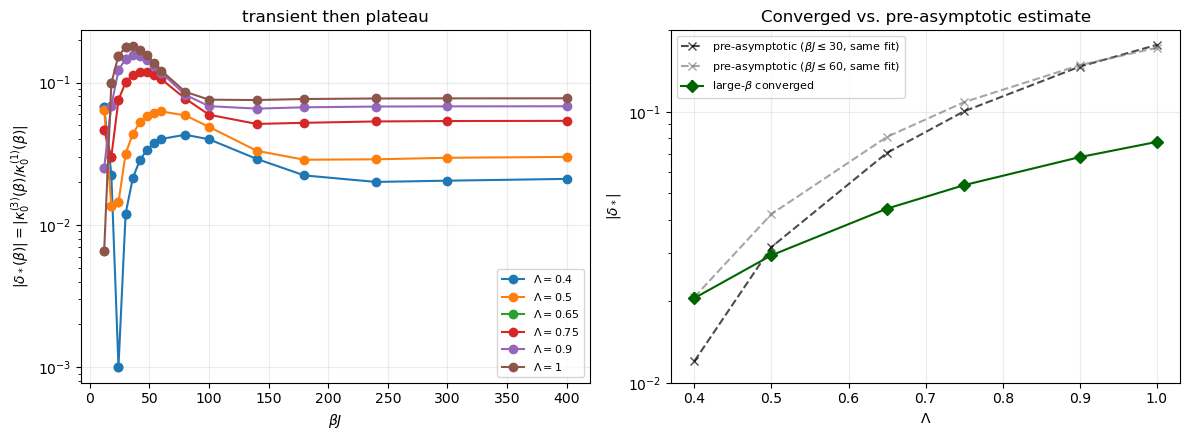

In [74]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes[0]
traj = kappa_df[np.isclose(kappa_df["Lambda"], 0.40)].sort_values("beta")
ax.plot(traj["betaJ"], 1/np.abs(traj["kappa0_1"]/traj["kappa0_3"]), "o-",label = r"$\Lambda = 0.4$")
traj = kappa_df[np.isclose(kappa_df["Lambda"], 0.50)].sort_values("beta")
ax.plot(traj["betaJ"], 1/np.abs(traj["kappa0_1"]/traj["kappa0_3"]), "o-",label = r"$\Lambda = 0.5$")
traj = kappa_df[np.isclose(kappa_df["Lambda"], 0.64)].sort_values("beta")
ax.plot(traj["betaJ"], 1/np.abs(traj["kappa0_1"]/traj["kappa0_3"]), "o-",label = r"$\Lambda = 0.65$")
traj = kappa_df[np.isclose(kappa_df["Lambda"], 0.75)].sort_values("beta")
ax.plot(traj["betaJ"], 1/np.abs(traj["kappa0_1"]/traj["kappa0_3"]), "o-",label = r"$\Lambda = 0.75$")
traj = kappa_df[np.isclose(kappa_df["Lambda"], 0.9)].sort_values("beta")
ax.plot(traj["betaJ"], 1/np.abs(traj["kappa0_1"]/traj["kappa0_3"]), "o-",label = r"$\Lambda = 0.9$")
traj = kappa_df[np.isclose(kappa_df["Lambda"], 1)].sort_values("beta")
ax.plot(traj["betaJ"],1/np.abs(traj["kappa0_1"]/traj["kappa0_3"]), "o-",label = r"$\Lambda = 1$")

ax.set_xlabel(r"$\beta J$")
ax.set_ylabel(r"$|\delta_*(\beta)| = |\kappa_0^{(3)}(\beta)/\kappa_0^{(1)}(\beta)|$")
ax.set_title(r"transient then plateau")
ax.set_yscale('log')
ax.legend(fontsize=8)
ax.grid(alpha=0.25)

ax = axes[1]
ax.errorbar(
    kappa_converged_df["Lambda"], np.abs(kappa_converged_df["delta_star_converged"]),
    yerr=kappa_converged_df["convergence_spread"], fmt="D-", color="darkgreen",
    label=r"large-$\beta$ converged",
)
ax.plot(
    kappa_converged_df["Lambda"], np.abs(kappa_converged_df["small_delta_star_preasymptotic"]), "x--",
    color="black", alpha=0.7, label=r"pre-asymptotic ($\beta J\leq30$, same fit)",
)
ax.plot(
    kappa_converged_df["Lambda"], np.abs(kappa_converged_df["delta_star_preasymptotic"]), "x--",
    color="gray", alpha=0.7, label=r"pre-asymptotic ($\beta J\leq60$, same fit)",
)
ax.axhline(0.0, linewidth=0.5, color="gray")
ax.set_xlabel(r"$\Lambda$")
ax.set_ylabel(r"$|\delta_*|$")
ax.set_yscale('log')
ax.set_ylim((0.01,0.2))
ax.set_title("Converged vs. pre-asymptotic estimate")
ax.legend(fontsize=8)
ax.grid(alpha=0.25)

fig.tight_layout()
plt.show()